# Deriving Upper Bound on Cost for Hypervolume Metric

This notebook gives a walkthrough to the computation of the **largest conceivable daily cost** for the building‑level scenario **with (Scenario 1) and without (Scenario 2) a heat pump**. We will use the CSV data sources from the `./commonpower/finetuning/data/` directory provided in the project:

* `ICLR_load.csv` – baseline building load (MW)
* `ICLR_pv.csv` – PV generation (MW)
* `ToU_prices.csv` – grid buying price (€/MWh)

The result of this notebook will serve as the **lower bound on the reward function** (because reward = −cost) for the PCN approach when computing the hypervolume metric.

### Imports / File Paths / CSV Parsing

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path().resolve().parent / 'finetuning/data'

LOAD_FILE = BASE_DIR / 'ICLR_load.csv'
PV_FILE = BASE_DIR / 'ICLR_pv.csv'
PRICE_FILE = BASE_DIR / 'ToU_prices.csv'

#####################################################################

load = pd.read_csv(LOAD_FILE, parse_dates=['t']).rename(columns={'p':'load_MW'})
pv   = pd.read_csv(PV_FILE,   parse_dates=['t']).rename(columns={'p':'pv_MW'})
prices = (pd.read_csv(PRICE_FILE, parse_dates=['t'])
            .rename(columns={'psib_mwh':'price_EUR_per_MWh'}))

for df, name in [(load,'Load'), (pv,'PV'), (prices,'Prices')]:
    print(f"{name:7}: {df.shape[0]:5d} rows, time span {df['t'].min()} → {df['t'].max()}")

Load   :  8784 rows, time span 2016-01-01 00:00:00 → 2016-12-31 23:00:00
PV     :  8784 rows, time span 2016-01-01 00:00:00 → 2016-12-31 23:00:00
Prices :  8784 rows, time span 2016-01-01 00:00:00 → 2016-12-31 23:00:00


Testreference for the above output:
```python
Load   :  8784 rows, time span 2016-01-01 00:00:00 → 2016-12-31 23:00:00
PV     :  8784 rows, time span 2016-01-01 00:00:00 → 2016-12-31 23:00:00
Prices :  8784 rows, time span 2016-01-01 00:00:00 → 2016-12-31 23:00:00
```

> **FYI - Unit conventions**
>
> * Load & PV columns are given in **MW** (Megawatts).  
> * Prices are in **€/MWh**. To convert to **€/kWh** divide by 1000.  
> * Each row represents a **1‑hour** interval. Therefore the energy purchased in that interval is equal to `Net_Load_kW * 1 h = kWh`.

# Scenario 1: Lower Bound without a Heat Pump

We compute the worst-case daily electricity cost based on building base load, PV generation, and time-of-use grid prices (`ToU_prices.csv`).
The largest daily cost (upper-bound cost ⇒ lower-bound reward) in 2016 is thus calculated.

### 1. Net Load (MW)
For each 1h interval $t$ we determine the power that must be taken from or exported to the grid by calculating:

$\text{Net Load}_{t}\;[\text{MW}] \;=\; \text{Load}_{t}\;[\text{MW}] \;-\; \text{PV}_{t}\;[\text{MW}]$

### 2. Interval Cost (Euro)

We want an upper-bound (thus worst-case) cost so we:

* **pay** for every positive net-load (imports)
* **do not earn** revenue for exports (negative net-load is zero-clipped)

With hourly data the conversion is straightforward:

$$
\text{Cost}_{t} \;=\; 
\max\!\bigl(0,\text{Net Load}_{t}\bigr)
\;\cdot\;
\text{Price}_{t} \;[\text{Euro}/ \text{MWh}]
$$

*Note that because $MW \cdot 1 h = MWh$, we can directly use that formula without extra scaling what so ever.*

### 3. Daily Cost (Euro)

Sum all 24 hourly costs in a day:

$$
\text{Daily Cost}_{d} 
\;=\;
\sum_{t\in d}\text{Cost}_{t}
$$

### 4. Maximum Daily Cost

Find the largest $\text{Daily Cost}_{d}$ over the whole year.

## 1. Compute Net Load and Preprocessing 

In [14]:
# Merge on timestamp
df = (load.merge(pv, on='t', how='inner').merge(prices[['t','price_EUR_per_MWh']], on='t'))

# Convert MW -> kW so that multiplying by hours = kWh
df['load_kW'] = df['load_MW'] * 1_000
df['pv_kW']   = df['pv_MW']   * 1_000

# Net load (positive means we import from the grid, negative means we export)
df['net_load_kW'] = df['load_kW'] - df['pv_kW']

## 2. Worst‑Case Interval Cost
For the *upper‑bound* (worst case) we assume:

* We pay for every positive net kW (imports).
* We do not receive credits for exporting (-> negative net load is capped at 0).

Interval cost in Euro:
` Cost_interval = max(0, net_load_kW) * (price_EUR_per_MWh / 1000) `

In [15]:
df['price_EUR_per_kWh'] = df['price_EUR_per_MWh'] / 1_000
df['interval_cost_EUR'] = df['net_load_kW'].clip(lower=0) * df['price_EUR_per_kWh']

print("Interval cost statistics (EUR):")
print(df['interval_cost_EUR'].describe(percentiles=[0.9, 0.99]))

Interval cost statistics (EUR):
count    8784.000000
mean        2.849758
std         4.172849
min        -4.637646
50%         1.195215
90%         8.157311
99%        18.322361
max        44.494380
Name: interval_cost_EUR, dtype: float64


## 3. Aggregate to Daily Cost

In [16]:
df['date'] = df['t'].dt.date
daily_cost = df.groupby('date')['interval_cost_EUR'].sum().sort_values(ascending=False)

print(f"Max daily cost: {daily_cost.iloc[0]:.2f} € on {daily_cost.index[0]}")

daily_cost.head()

Max daily cost: 324.57 € on 2016-12-06


date
2016-12-06    324.569755
2016-12-04    323.986229
2016-12-16    307.204150
2016-01-21    302.518262
2016-12-14    279.989112
Name: interval_cost_EUR, dtype: float64

Therefore the **Result for the lower bound** in Scenario 1 is given by: **€ 324.57** on **2016-12-06**

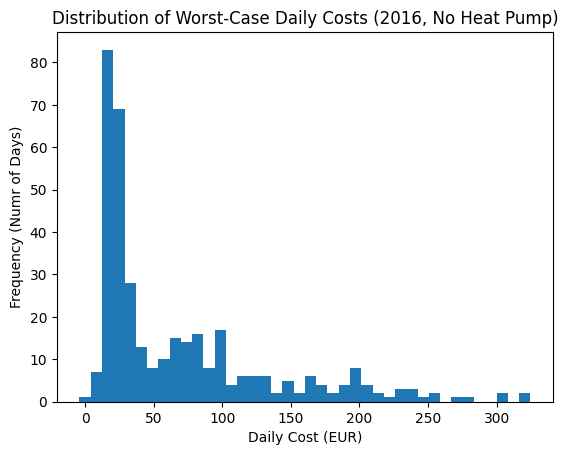

In [17]:
plt.figure()
daily_cost.plot(kind='hist', bins=40)
plt.xlabel('Daily Cost (EUR)')
plt.ylabel('Frequency (Numr of Days)')
plt.title('Distribution of Worst‑Case Daily Costs (2016, No Heat Pump)')
plt.show()

# Scenario 2: Lower Bound with a Heat Pump

Now we are adding the electrical consumption of a **monovalent air‑to‑water heat pump** and the corresponding **comfort‑penalty** term.  The result gives a **lower bound on reward** (upper bound on cost + penalty) again for hyper‑volume metrics. Again we need the Data sources as above:

* `ICLR_load.csv` – baseline building load (MW)
* `ICLR_pv.csv` – PV generation (MW)
* `ToU_prices.csv` – grid buying price (€/MWh)

For the heat pump scenario we also need to consider:
* `DE_Temperature_and_COP2016.csv` – outside temperature and heat‑pump COP (hourly)


### 1. Heating Load Calculation

The heating load of the building is calculated for each 1h interval *t*. The formula and terminology are adapted from the *2001 ASHRAE Handbook—Fundamentals, Chapter 29, "Nonresidential Cooling and Heating Load Calculations."*

$$q_t = (U \cdot A) \cdot \max(0, t_i - t_{o,t})$$

Where:
* $q_t$ - Rate of heat loss for the interval *t*, in [kW]. This is the thermal demand that the heat pump must meet.
* $U$ - Overall coefficient of heat transmission in [kW/(m²·K)]. It represents the thermal conductivity of the entire building.
* $A$ - Surface area of the building in [m²]. For this analysis, the term $(U \cdot A)$ is treated as a single, aggregated overall heat-loss coefficient in [kW/K].
* $t_i$ - Indoor design temperature, which corresponds to the heating setpoint $T_{\text{set}}$ -> e.g., 21 °C
* $t_{o,t}$ - Outdoor design temperature for the interval *t*, taken from the weather data file `DE_Temperature_and_COP2016.csv`.


### 2. Heat-Pump Electrical Power $P_{\text{hp}}$

$$
P_{\text{hp},t}\,[\text{kW}] 
= \min\!\Bigl(\tfrac{Q_{\text{th},t}}{\text{COP}_t},\; P_{\text{hp,max}}\Bigr)
$$

* COP comes from the same CSV; zero values are excluded.
* $P_{\text{hp,max}}$ is the action-space ceiling (default 15 kW).


### 3. Net Load (kW)

$$
\text{Net Load}_{t} 
= \text{Base Load}_{t}  + P_{\text{hp},t} - \text{PV}_{t}
$$

(Base Load and PV are read from **`ICLR_load.csv`** and **`ICLR_pv.csv`**.)


### 4. Interval Cost (Euro)

Pay only for imports, ignore any export revenue (as in Scenario 1):

$$
\text{Cost}_{t} \;=\; 
\max\!\bigl(0,\text{Net Load}_{t}\bigr)
\;\cdot\;
\text{Price}_{t} \;[\text{Euro}/ \text{MWh}]
$$


### 5. Daily Cost

$$
\text{Daily Cost}_{d} 
= \sum_{t\in d} \text{Cost}_{t}
$$

The maximum across 2016 is **€ 332.46 on 6 Dec 2016** (see Scenario 1).


### 6. Discomfort-Penalty Upper Bound

Assume worst-case penalty of `PENALTY_MAX` per hour wich is applied every hour:

$$
\text{Penalty}_{\text{max, day}} 
= \text{PENALTY\_MAX} \cdot 24
$$

With the defaults (`PENALTY_MAX = 3`), that is **72.00**.



We compute the worst-case daily electricity cost based on building base load, PV generation, and time-of-use grid prices (`ToU_prices.csv`).
The largest daily cost (upper-bound cost ⇒ lower-bound reward) in 2016 is thus calculated.

### 1. Net Load (MW)
For each 1h interval $t$ we determine the power that must be taken from or exported to the grid by calculating:

$\text{Net Load}_{t}\;[\text{MW}] \;=\; \text{Load}_{t}\;[\text{MW}] \;-\; \text{PV}_{t}\;[\text{MW}]$

### 2. Interval Cost (Euro)

We want an upper-bound (thus worst-case) cost so we:

* **pay** for every positive net-load (imports)
* **do not earn** revenue for exports (negative net-load is zero-clipped)

With hourly data the conversion is straightforward:

$$
\text{Cost}_{t} \;=\; 
\max\!\bigl(0,\text{Net Load}_{t}\bigr)
\;\cdot\;
\text{Price}_{t} \;[\text{Euro}/ \text{MWh}]
$$

*Note that because $MW \cdot 1 h = MWh$, we can directly use that formula without extra scaling what so ever.*

### 3. Daily Cost (Euro)

Sum all 24 hourly costs in a day:

$$
\text{Daily Cost}_{d} 
\;=\;
\sum_{t\in d}\text{Cost}_{t}
$$

### 4. Maximum Daily Cost

Find the largest $\text{Daily Cost}_{d}$ over the whole year.

### Imports / File Paths / CSV Parsing & Parameters to fill in

In [18]:
import pandas as pd
import numpy as np

BASE_DIR = Path().resolve().parent / 'finetuning/data'

LOAD_FILE = BASE_DIR / 'ICLR_load.csv'
PV_FILE = BASE_DIR / 'ICLR_pv.csv'
PRICE_FILE = BASE_DIR / 'ToU_prices.csv'
HP_FILE    = BASE_DIR / 'DE_Temperature_and_COP2016.csv'

# These values are derived directly from scenarios.py
P_HP_MAX = 5.0      # kW -> Correct value from HeatPumpWithoutStorageButCOP config {'p': [0, 5]}
T_SET    = 21.0     # Celsius -> From HeatPumpWithoutStorageButCOP config {'T_indoor_setpoint': 21}

# These values are simplifying assumptions for the bounding calculation, as they are not defined as single constants in scenarios.py.
UA          = 0.75  # kW/K -> Assumed overall heat-loss coefficient. -> educated guess
PENALTY_MAX = 3.0   # Units -> Assumed worst-case discomfort penalty per hour. Derived from controllers.py -> RLControllerSB3._calculate_reward -- reward -= 3.0 * (1.0 - soc_reward)

# General parameter
EPISODE_H = 24      # hours per RL episode

## 2. Read & Merge Data

In [19]:
# Base electricity & PV
load  = pd.read_csv(LOAD_FILE, parse_dates=['t']).rename(columns={'p':'load_MW'})
pv    = pd.read_csv(PV_FILE,   parse_dates=['t']).rename(columns={'p':'pv_MW'})
price = pd.read_csv(PRICE_FILE, parse_dates=['t'])[['t','psib_mwh']].rename(columns={'psib_mwh':'price_EUR_per_MWh'})

# Heat‑pump data: outside temp, COP
hp = (pd.read_csv(HP_FILE, sep=';')
        .rename(columns={'time':'t', 'outside_temp':'Tout_C', 'COP':'COP'})
        .astype({'COP':float, 'Tout_C':float}))
hp['t'] = pd.to_datetime(hp['t'], format='%d.%m.%Y %H:%M')

# Merge everything hourly
df = (load.merge(pv, on='t')
          .merge(price, on='t')
          .merge(hp[['t','Tout_C','COP']], on='t'))

## 3. Heat Demand & Heat‑Pump Electrical Power

In [20]:

df['Q_th_kW'] = (T_SET - df['Tout_C']).clip(lower=0) * UA

df['P_hp_kW'] = np.minimum(df['Q_th_kW'] / df['COP'].replace(0, np.nan), P_HP_MAX)


## 4. Net Load & Worst‑Case Interval Cost

In [21]:
# See Scenario 1 
df['load_kW'] = df['load_MW'] * 1_000
df['pv_kW']   = df['pv_MW']   * 1_000

df['net_kW']  = df['load_kW'] + df['P_hp_kW'] - df['pv_kW']

df['price_EUR_per_kWh'] = df['price_EUR_per_MWh'] / 1_000

df['interval_cost_EUR'] = df['net_kW'].clip(lower=0) * df['price_EUR_per_kWh']


## 5. Discomfort Penalty Upper‑Bound

In [22]:
df['episode_idx'] = (df.index // EPISODE_H).astype(int)

# Max possible discomfort for a episode = PENALTY_MAX * EPISODE_H
penalty_upper_bound = PENALTY_MAX * EPISODE_H


## 6. Aggregate to Daily (or Episode‑length) Cost & Find Worst Case

In [23]:
df['date'] = df['t'].dt.date
daily_cost = df.groupby('date')['interval_cost_EUR'].sum().sort_values(ascending=False)

worst_cost  = daily_cost.iloc[0]
worst_day   = daily_cost.index[0]

print(f"Max daily cost: €{worst_cost:,.2f} on {worst_day}")
print(f"Discomfort penalty upper‑bound per day : {penalty_upper_bound:.2f}")
print(f"→ Lower‑bound reward = -(cost + penalty) = {-(worst_cost + penalty_upper_bound):.2f}")

Max daily cost: €330.48 on 2016-12-06
Discomfort penalty upper‑bound per day : 72.00
→ Lower‑bound reward = -(cost + penalty) = -402.48


# Action Space Diameter

The action space is the set of all possible commands the agent can send to the controllable devices. The diameter of this space represents the total range of control.

#### Scenario 1: Without Heat Pump
In this scenario, the agent only controls the battery (`ESS1`). Therefore the Action Space is just 1-dimensional with the battery power $p_{batt}$.

* Range (`p_batt`): `[-1.5, 1.5]` kW, from `scenarios.py`
* Diameter:
    $d_1 = \|p_{max} - p_{min}\| = 1.5 - (-1.5) = 3.0$

#### Scenario 2: With Heat Pump
In this scenario, the agent controls the battery (`ESS1`) and the heat pump (`HeatPump`). Therefore the Action Space is 2-dimensional (battery power $p_{batt}$, heat pump power $p_{hp}$).

* Battery Range (`p_batt`): `[-1.5, 1.5]` kW
* Heat Pump Range (`p_hp`): `[0, 5.0]` kW, from `scenarios.py`
* Diameter per Dimension:
    * $d_{batt} = 1.5 - (-1.5) = 3.0$
    * $d_{hp} = 5.0 - 0 = 5.0$
* Diameter in total:
    * $d_{2} = \|p_{max} - p_{min}\|_2 = \sqrt{3.0^2 + 5.0^2} = \sqrt{34.0} \approx 5.83$


